# Aliasing and the Sampling Theorem

**A hands-on exploration**

*Final project — Approximation course*

---

This notebook tells a story in five acts:

1. **The mystery.** A signal that lies about its own frequency.
2. **The theorem.** Why it lies, and when.
3. **The sound of it.** What aliasing sounds like to a human ear.
4. **Putting it back together.** Three ways to reconstruct a sampled signal,
   and how they compare.
5. **Play with it.** An interactive widget for exploring the parameter space.

Run the cells in order. Every figure is reproducible from the code in this
notebook alone — no external data files are required.

## Act 1 — The mystery

Here is a perfectly ordinary 440 Hz sine wave. That's the pitch of a tuning
fork, the A above middle C.

We're going to sample it twice. The first time, everything will work as
expected. The second time, something strange will happen.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Style: clean, readable, consistent across the notebook
plt.rcParams.update({
    "figure.figsize": (10, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

### The signal

We define a 440 Hz sine wave on the interval $[0, 0.02]$ seconds — that's
20 milliseconds, long enough to contain about 9 full oscillations. We
represent it as a dense set of points to mimic the underlying continuous
signal.

In [2]:
# Signal parameters
f_signal = 440.0          # Hz — the frequency of our sine wave
duration = 0.02           # seconds — 20 ms window

# A dense grid that approximates the "true" continuous signal
fs_dense = 200_000        # Hz — far above any sample rate we'll use
t_dense = np.arange(0, duration, 1 / fs_dense)
x_dense = np.sin(2 * np.pi * f_signal * t_dense)

print(f"Continuous signal: {len(t_dense)} points over {duration*1000:.0f} ms")

Continuous signal: 4000 points over 20 ms


### Sampling, take 1: a "reasonable" sample rate

We sample the signal at $f_s = 8000$ Hz. That gives us one sample every
0.125 ms.

In [3]:
# Sampling parameters — take 1
fs_good = 8000            # Hz
t_good = np.arange(0, duration, 1 / fs_good)
x_good = np.sin(2 * np.pi * f_signal * t_good)

print(f"At fs = {fs_good} Hz, we get {len(t_good)} samples in {duration*1000:.0f} ms")

At fs = 8000 Hz, we get 160 samples in 20 ms


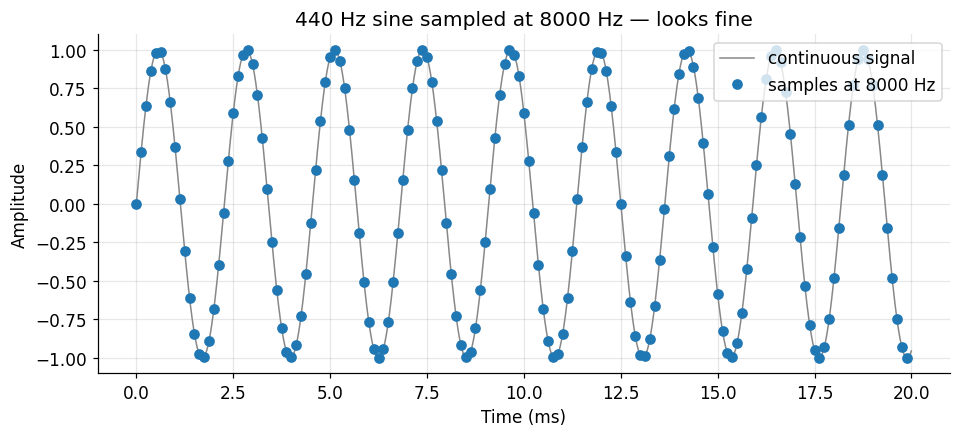

In [4]:
fig, ax = plt.subplots()
ax.plot(t_dense * 1000, x_dense, color="#888", linewidth=1, label="continuous signal")
ax.plot(t_good * 1000, x_good, "o", color="#1f77b4", markersize=6,
        label=f"samples at {fs_good} Hz")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_title("440 Hz sine sampled at 8000 Hz — looks fine")
ax.legend(loc="upper right")
plt.show()

The samples (blue dots) trace out the underlying sine wave (gray) faithfully.
If we connected the dots with a smooth curve, we would recover the original.

Now let's confirm this in the frequency domain. We compute the discrete
Fourier transform of the sampled signal — but to keep the spectrum readable,
we'll use a longer time window for this analysis.

In [5]:
def compute_spectrum(x, fs):
    """Return (freqs, magnitude) for the positive-frequency half of the FFT."""
    N = len(x)
    X = np.fft.fft(x)
    freqs = np.fft.fftfreq(N, d=1 / fs)
    # Keep only positive frequencies, normalize magnitude
    half = N // 2
    return freqs[:half], np.abs(X[:half]) * 2 / N

# Use a longer window (0.5 s) for a cleaner spectrum
t_long_good = np.arange(0, 0.5, 1 / fs_good)
x_long_good = np.sin(2 * np.pi * f_signal * t_long_good)
freqs_good, mag_good = compute_spectrum(x_long_good, fs_good)

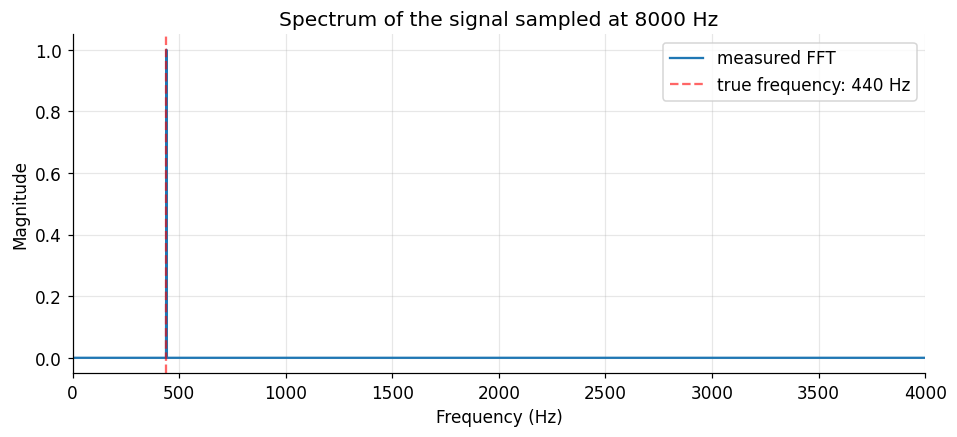

In [6]:
fig, ax = plt.subplots()
ax.plot(freqs_good, mag_good, color="#1f77b4", label="measured FFT")
ax.axvline(f_signal, color="red", linestyle="--", alpha=0.6,
           label=f"true frequency: {f_signal:.0f} Hz")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title(f"Spectrum of the signal sampled at {fs_good} Hz")
ax.set_xlim(0, fs_good / 2)
ax.legend(loc="upper right")
plt.show()

A clean spike at exactly 440 Hz. The dashed red line confirms it. So far,
nothing strange.

### Sampling, take 2: a "low" sample rate

Now we sample the *same* 440 Hz signal at $f_s = 600$ Hz instead.

In [7]:
# Sampling parameters — take 2
fs_bad = 600              # Hz
t_bad = np.arange(0, duration, 1 / fs_bad)
x_bad = np.sin(2 * np.pi * f_signal * t_bad)

print(f"At fs = {fs_bad} Hz, we get {len(t_bad)} samples in {duration*1000:.0f} ms")

At fs = 600 Hz, we get 12 samples in 20 ms


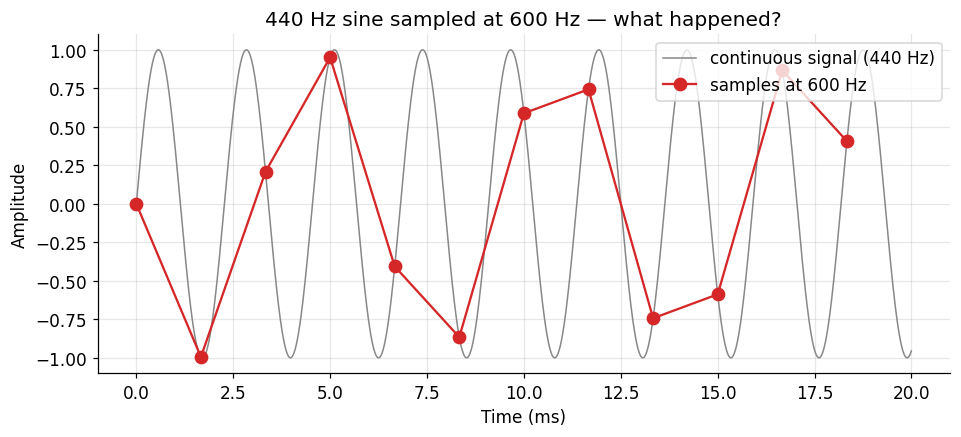

In [8]:
fig, ax = plt.subplots()
ax.plot(t_dense * 1000, x_dense, color="#888", linewidth=1, label="continuous signal (440 Hz)")
ax.plot(t_bad * 1000, x_bad, "o-", color="#d62728", markersize=8,
        label=f"samples at {fs_bad} Hz")
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_title("440 Hz sine sampled at 600 Hz — what happened?")
ax.legend(loc="upper right")
plt.show()

The samples no longer trace the original signal. If we drew a smooth curve
through the red dots — ignoring the gray underlying signal we already know —
we would conclude the signal has a much *lower* frequency than 440 Hz.

The frequency domain confirms it.

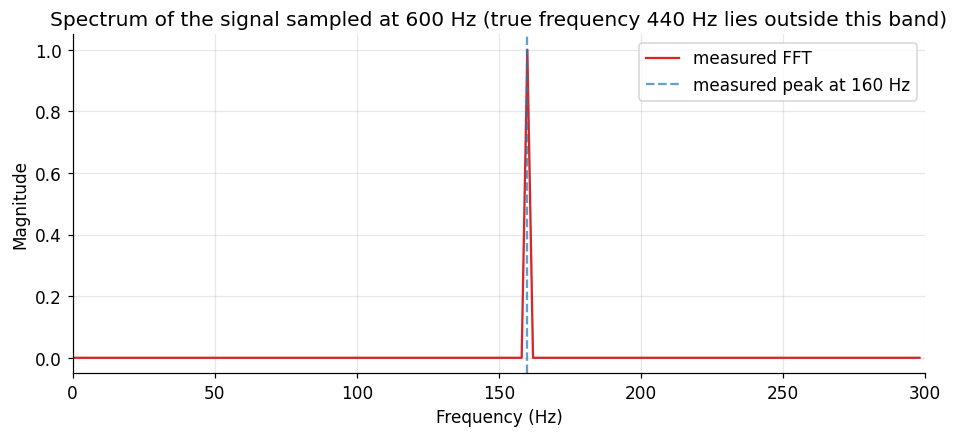

In [9]:
# Same long-window trick for a clean spectrum
t_long_bad = np.arange(0, 0.5, 1 / fs_bad)
x_long_bad = np.sin(2 * np.pi * f_signal * t_long_bad)
freqs_bad, mag_bad = compute_spectrum(x_long_bad, fs_bad)

# Predicted alias for annotation
f_alias = abs(f_signal - round(f_signal / fs_bad) * fs_bad)

fig, ax = plt.subplots()
ax.plot(freqs_bad, mag_bad, color="#d62728", label="measured FFT")
ax.axvline(f_alias, color="#1f77b4", linestyle="--", alpha=0.7,
           label=f"measured peak at {f_alias:.0f} Hz")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Magnitude")
ax.set_title(f"Spectrum of the signal sampled at {fs_bad} Hz "
             f"(true frequency 440 Hz lies outside this band)")
ax.set_xlim(0, fs_bad / 2)
ax.legend(loc="upper right")
plt.show()

The spectrum shows a sharp peak — but **not** at 440 Hz. The true frequency
is even outside the plot's range (the spectrum can only show frequencies up
to $f_s / 2 = 300$ Hz when $f_s = 600$ Hz).

The peak appears at a frequency that has nothing to do with 440 Hz at first
glance — but as we'll see in Act 2, it has *everything* to do with it.

This is **aliasing**: a high-frequency signal pretending to be a
low-frequency one because the sample rate isn't fast enough to tell them
apart.

The rest of this notebook answers four questions:

1. *Why* does this happen? (Act 2)
2. What does it sound like? (Act 3)
3. Once we have the samples, how do we put the signal back together? (Act 4)
4. What if we want to play with the parameters ourselves? (Act 5)

## Act 2 — The theorem

What we just saw has a name and a precise mathematical condition.

> **Nyquist–Shannon sampling theorem.** A continuous signal whose Fourier
> transform is zero outside the band $[-f_\text{max}, f_\text{max}]$ can be
> exactly reconstructed from its samples if and only if the sample rate
> satisfies $f_s > 2 f_\text{max}$.
>
> The threshold $2 f_\text{max}$ is called the **Nyquist rate**.

For our 440 Hz sine, $f_\text{max} = 440$ Hz, so the Nyquist rate is 880 Hz.
At $f_s = 8000$ Hz we were comfortably above it; at $f_s = 600$ Hz we were
below it, and the signal aliased.

But the theorem doesn’t tell us *where* the aliased peak ends up. For that
we need a picture.

### Why does sampling create copies of the spectrum?

A central fact about the Fourier transform — which we take as given — is:

> **Sampling a signal in time creates periodic copies of its spectrum in
> frequency, spaced $f_s$ apart.**

If the original signal has a peak at frequency $f$, the *sampled* signal’s
spectrum contains peaks at $f$, $f \pm f_s$, $f \pm 2 f_s$, and so on.

When $f_s$ is large, those copies are far apart and don’t interfere with
each other. When $f_s$ is small, the copies start to overlap — and a peak
from one copy can land inside the visible band $[0, f_s/2]$ of the next.
That’s aliasing.

The visualization below makes this concrete.

In [10]:
def spectrum_with_copies(f_signal, fs, f_view_max):
    """
    Return the location of every spectral peak (positive and negative) for
    a sine of frequency f_signal sampled at fs, within a viewing window
    [-f_view_max, f_view_max].

    A real sinusoid has peaks at +f and -f. Sampling replicates them at
    every multiple of fs.
    """
    peaks = []
    # How many copies of fs we need to consider on each side
    n_copies = int(np.ceil(f_view_max / fs)) + 1
    for k in range(-n_copies, n_copies + 1):
        for sign in (+1, -1):
            peak = sign * f_signal + k * fs
            if -f_view_max <= peak <= f_view_max:
                peaks.append(peak)
    return peaks


def plot_folding(ax, f_signal, fs, f_view_max=2500):
    """Draw spectrum copies on a single axis."""
    peaks = spectrum_with_copies(f_signal, fs, f_view_max)

    # Mark the visible band [-fs/2, fs/2] — what the sampled spectrum can
    # actually represent
    ax.axvspan(-fs / 2, fs / 2, color="#ffe9b3", alpha=0.5,
               label=f"visible band $[-f_s/2, f_s/2]$")

    # Draw every spectral peak as a vertical line
    for p in peaks:
        # Color: blue if it’s within the visible band, gray otherwise
        in_band = -fs / 2 <= p <= fs / 2
        color = "#1f77b4" if in_band else "#bbbbbb"
        ax.axvline(p, color=color, linewidth=2, alpha=0.9 if in_band else 0.6)

    # Mark the original signal frequency for reference
    ax.axvline(f_signal, color="red", linestyle="--", linewidth=1, alpha=0.7,
               label=f"original $f = {f_signal:.0f}$ Hz")
    ax.axvline(-f_signal, color="red", linestyle="--", linewidth=1, alpha=0.7)

    ax.set_xlim(-f_view_max, f_view_max)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel("Frequency (Hz)")
    ax.set_title(f"$f_s = {fs}$ Hz" + (" — aliasing" if fs < 2 * f_signal else " — safe"))
    ax.legend(loc="upper right", fontsize=9)

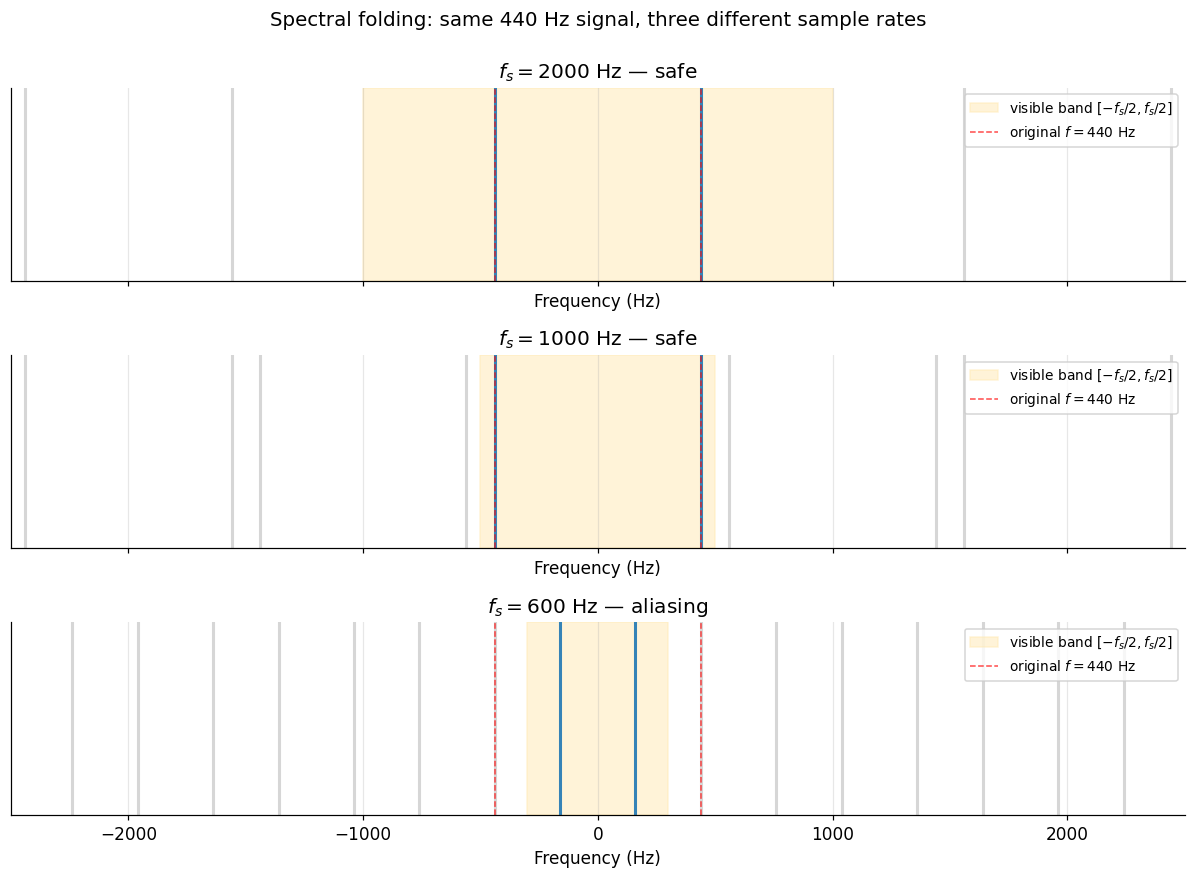

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
fig.suptitle("Spectral folding: same 440 Hz signal, three different sample rates",
             fontsize=13, y=0.995)

plot_folding(axes[0], f_signal=440, fs=2000)   # well above Nyquist
plot_folding(axes[1], f_signal=440, fs=1000)   # just above Nyquist
plot_folding(axes[2], f_signal=440, fs=600)    # below Nyquist — same as Act 1

plt.tight_layout()
plt.show()

Read the figure top to bottom.

- **Top panel** ($f_s = 2000$ Hz). The visible band (yellow) is wide. The
  original peaks at $\pm 440$ Hz sit comfortably inside it. The neighboring
  copies — at $2000 \pm 440 = 1560$ and $2440$ Hz — are far outside. No
  collision.

- **Middle panel** ($f_s = 1000$ Hz, just above Nyquist of 880 Hz). The
  visible band has narrowed. The 440 Hz peak still sits inside, but the
  neighboring copy at $1000 - 440 = 560$ Hz is now close to the edge.
  Cutting it any finer would cause trouble.

- **Bottom panel** ($f_s = 600$ Hz, below Nyquist). The visible band is
  narrow enough that the copy from $f_s$ has slid *into* it. The peak at
  $600 - 440 = 160$ Hz is now inside the visible band — and indistinguishable
  from a real 160 Hz signal. **That is exactly the peak we saw in Act 1.**

The aliased frequency is the location of the spectral copy that has folded
into the visible band. For a sine of frequency $f$ sampled at $f_s$, the
formula is:

$$
f_\text{alias} = \min_{k \in \mathbb{Z}} |f - k \cdot f_s|
$$

i.e. the distance from $f$ to the nearest integer multiple of $f_s$.

### Verification: predicting where the alias lands

Let’s verify the formula on a few cases. For each $(f_\text{signal}, f_s)$
pair, we predict the aliased frequency, then sample the signal, run an FFT,
and check that the peak is where we said it would be.

In [12]:
def predicted_alias(f_signal, fs):
    """Distance from f_signal to the nearest integer multiple of fs."""
    k = round(f_signal / fs)
    return abs(f_signal - k * fs)


def measured_peak(f_signal, fs, duration=1.0):
    """Sample the signal and return the frequency of the largest FFT peak."""
    t = np.arange(0, duration, 1 / fs)
    x = np.sin(2 * np.pi * f_signal * t)
    freqs, mag = compute_spectrum(x, fs)
    return freqs[np.argmax(mag)]


# Test cases — each chosen to illustrate a different folding scenario
test_cases = [
    (440,  8000),   # well sampled
    (440,  1000),   # just above Nyquist
    (440,   600),   # the Act 1 case
    (440,   500),   # closer to f_signal — alias creeps lower
    (1000,  700),   # signal above fs: heavy aliasing
    (3000, 8000),   # well sampled, higher frequency
    (4500, 8000),   # right at Nyquist of 8000 — borderline
]

print(f"{'f_signal':>10} {'fs':>8} {'predicted':>12} {'measured':>12} {'match':>8}")
print("-" * 56)
for f_sig, fs in test_cases:
    pred = predicted_alias(f_sig, fs)
    meas = measured_peak(f_sig, fs)
    match = "✓" if abs(pred - meas) < 2.0 else "✗"
    print(f"{f_sig:>10.0f} {fs:>8.0f} {pred:>10.1f} Hz {meas:>10.1f} Hz {match:>8}")

  f_signal       fs    predicted     measured    match
--------------------------------------------------------
       440     8000      440.0 Hz      440.0 Hz        ✓
       440     1000      440.0 Hz      440.0 Hz        ✓
       440      600      160.0 Hz      160.0 Hz        ✓
       440      500       60.0 Hz       60.0 Hz        ✓
      1000      700      300.0 Hz      300.0 Hz        ✓
      3000     8000     3000.0 Hz     3000.0 Hz        ✓
      4500     8000     3500.0 Hz     3500.0 Hz        ✓


Every prediction matches the measurement to within the FFT’s frequency
resolution (1 Hz, since we used a 1-second window).

The last row is the borderline case: a 4500 Hz signal sampled at 8000 Hz
is *just* above the Nyquist limit of 4000 Hz, so it aliases — to
$|4500 - 8000| = 3500$ Hz, which is what we measure.

We now have the theory we need. The next two acts are about consequences:
what aliasing **sounds like** (Act 3), and how to **undo** sampling
correctly when we did it right (Act 4).

## Act 3 — The sound of aliasing

So far, aliasing has been a story told in plots. Now we tell it through the
ear.

We will:

1. Generate a high-quality **chirp** — a tone that smoothly sweeps in
   frequency over a few seconds.
2. Sample it at a rate where everything is fine, and listen.
3. Downsample it carelessly, and listen to what aliasing does to a
   sweeping tone.
4. Downsample it correctly with an **anti-alias filter**, and listen to
   the difference.

Each step produces a `.wav` file you can play directly in this notebook
or open in any audio player.

In [13]:
import os
from pathlib import Path
import soundfile as sf
from scipy import signal as sps
from IPython.display import Audio, display

# Ensure the audio directory exists
AUDIO_DIR = Path("audio")
AUDIO_DIR.mkdir(exist_ok=True)
print(f"Audio output directory: {AUDIO_DIR.resolve()}")

Audio output directory: C:\Users\patri\OneDrive\Documente\IE_BAM\YEAR 2\Approximation\project_signaling\audio


### The reference signal: a 5-second chirp from 100 Hz to 5000 Hz

A **linear chirp** is a sinusoid whose instantaneous frequency increases
linearly with time. We use:

$$
x(t) = \sin\left(2\pi \left[f_0 t + \frac{f_1 - f_0}{2T} t^2\right]\right)
$$

with $f_0 = 100$ Hz, $f_1 = 5000$ Hz, and $T = 5$ s.

We sample at **44 100 Hz** — CD-quality audio. Since $f_1 = 5000$ Hz is
far below the Nyquist limit of 22 050 Hz, this sample rate is more than
sufficient. This is our trusted, alias-free reference.

In [14]:
# Reference signal parameters
f0 = 100        # Hz, chirp start frequency
f1 = 5000       # Hz, chirp end frequency
T = 5.0         # seconds, total duration
fs_ref = 44100  # Hz, reference sample rate (CD quality)

t_ref = np.arange(0, T, 1 / fs_ref)
chirp_ref = sps.chirp(t_ref, f0=f0, f1=f1, t1=T, method="linear")

# Save and play
ref_path = AUDIO_DIR / "chirp_reference_44100Hz.wav"
sf.write(ref_path, chirp_ref, fs_ref)
print(f"Saved: {ref_path} ({len(chirp_ref)} samples, {T:.1f} s)")

display(Audio(str(ref_path)))

Saved: audio\chirp_reference_44100Hz.wav (220500 samples, 5.0 s)


> **A note on Fourier analysis.** The spectrograms in this section are
> the Fourier transform applied to short, overlapping windows of the
> sampled signal. Each vertical stripe in a spectrogram is a single
> FFT. Reading the spectrogram from left to right is therefore reading
> the frequency content of the signal as it evolves in time — which is
> exactly the kind of analysis the sampling theorem is about. The
> aliasing we are about to hear shows up in these FFTs as energy
> appearing at frequencies the original signal never contained.

You should hear a clean tone rising smoothly from a low pitch to a
moderately high one over five seconds. No surprises.

Let's confirm with a spectrogram — a plot showing how the signal's
spectrum evolves over time. The bright diagonal line is the chirp's
instantaneous frequency rising linearly from 100 Hz to 5000 Hz.

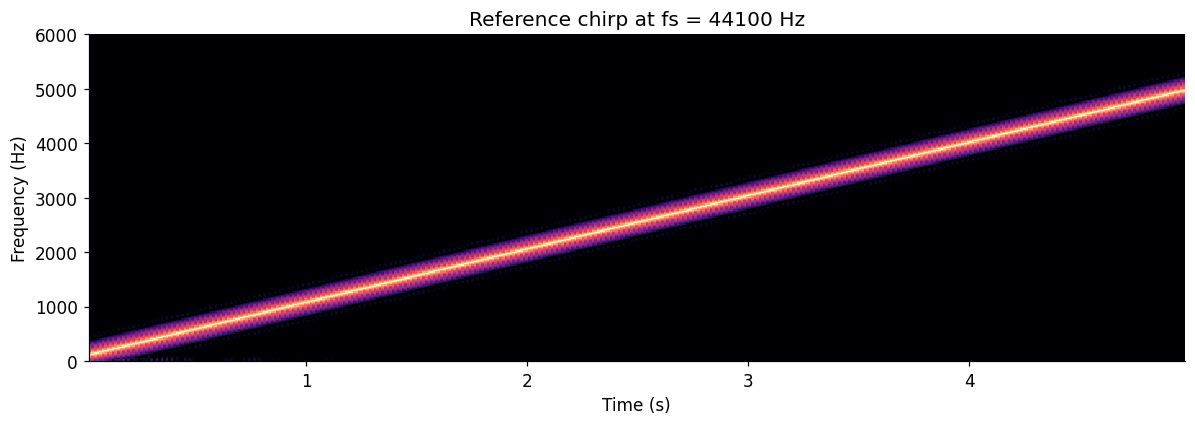

In [15]:
def plot_spectrogram(ax, x, fs, title, fmax=None):
    """Compact spectrogram plotter: time on x-axis, frequency on y-axis."""
    f, t, Sxx = sps.spectrogram(x, fs=fs, nperseg=2048, noverlap=1536)
    # Convert to dB for visibility
    Sxx_db = 10 * np.log10(Sxx + 1e-12)
    im = ax.pcolormesh(t, f, Sxx_db, shading="auto", cmap="magma",
                       vmin=Sxx_db.max() - 60, vmax=Sxx_db.max())
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Frequency (Hz)")
    ax.set_title(title)
    if fmax is not None:
        ax.set_ylim(0, fmax)
    ax.grid(False)
    return im

fig, ax = plt.subplots(figsize=(11, 4))
plot_spectrogram(ax, chirp_ref, fs_ref,
                 f"Reference chirp at fs = {fs_ref} Hz", fmax=6000)
plt.tight_layout()
plt.show()

### Naive downsampling: throwing samples away

Now we take the reference signal and reduce its sample rate by a factor of
11, simply by **keeping every 11th sample**. The new sample rate is
$44100 / 11 \approx 4009$ Hz, with a Nyquist limit of about 2004 Hz.

But our chirp goes up to 5000 Hz. Whatever happens to frequencies above
the new Nyquist limit?

In [16]:
# Naive decimation: keep every 11th sample, no filter
DECIMATE_FACTOR = 11
fs_low = fs_ref // DECIMATE_FACTOR  # ~ 4009 Hz
chirp_naive = chirp_ref[::DECIMATE_FACTOR]

print(f"New sample rate: {fs_low} Hz")
print(f"New Nyquist limit: {fs_low / 2:.0f} Hz")
print(f"Chirp passes Nyquist limit at t \u2248 "
      f"{(fs_low / 2 - f0) / (f1 - f0) * T:.2f} s")

naive_path = AUDIO_DIR / f"chirp_naive_{fs_low}Hz.wav"
sf.write(naive_path, chirp_naive, fs_low)
print(f"Saved: {naive_path}")

display(Audio(str(naive_path)))

New sample rate: 4009 Hz
New Nyquist limit: 2004 Hz
Chirp passes Nyquist limit at t ≈ 1.94 s
Saved: audio\chirp_naive_4009Hz.wav


Listen carefully. The pitch rises as expected — but partway through, it
**reverses direction** and starts falling. Then it may rise again, fall
again. By the end, the audible pitch has nothing to do with what the
"real" chirp is doing at that moment.

The spectrogram makes the geometry of this clear.

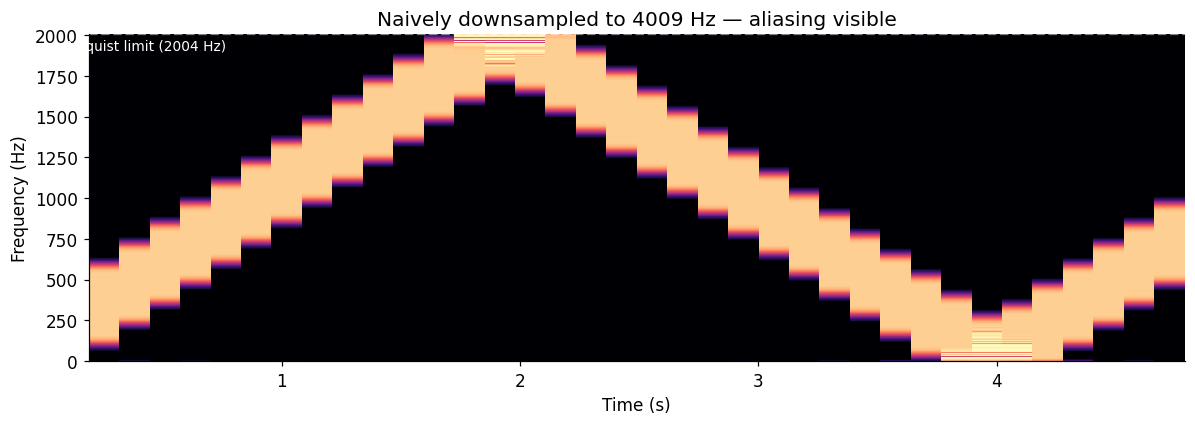

In [17]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_spectrogram(ax, chirp_naive, fs_low,
                 f"Naively downsampled to {fs_low} Hz — aliasing visible",
                 fmax=fs_low / 2)

# Annotate the Nyquist limit
ax.axhline(fs_low / 2, color="white", linestyle="--", alpha=0.5)
ax.text(0.1, fs_low / 2 - 100, f"Nyquist limit ({fs_low/2:.0f} Hz)",
        color="white", fontsize=9)
plt.tight_layout()
plt.show()

The chirp's instantaneous frequency hits the Nyquist limit at the time
predicted above, and then **folds back down**. Continue the chirp upward in
frequency and the alias keeps moving downward. Then once the *real*
frequency exceeds $f_s$, the alias starts climbing again — bouncing back
and forth between 0 Hz and the Nyquist limit, as predicted by the folding
formula from Act 2.

This is what aliasing sounds like: a signal that lies about its own pitch.

### Correct downsampling: filter first, then decimate

The fix is straightforward in principle: **before** reducing the sample
rate, remove every frequency above the new Nyquist limit. That way nothing
is left above the limit to alias.

`scipy.signal.decimate` does exactly this. It applies a low-pass
anti-alias filter at the new Nyquist limit, then keeps every Nth sample.

In [18]:
# Correct decimation: scipy.signal.decimate handles filtering + downsampling
chirp_correct = sps.decimate(chirp_ref, q=DECIMATE_FACTOR, ftype="fir")
print(f"Length matches: {len(chirp_correct) == len(chirp_naive)}")

correct_path = AUDIO_DIR / f"chirp_filtered_{fs_low}Hz.wav"
sf.write(correct_path, chirp_correct, fs_low)
print(f"Saved: {correct_path}")

display(Audio(str(correct_path)))

Length matches: True
Saved: audio\chirp_filtered_4009Hz.wav


This time the chirp rises until it reaches the new Nyquist limit
(~2004 Hz) — and then **goes silent**. No reversal, no folding, no
ghost pitches. The frequencies above the limit have been removed, so
there is nothing left to alias.

The information above 2 kHz is genuinely lost — we have not magically
recovered it — but the lower frequencies are still represented honestly.
This is the right tradeoff: lose what cannot be kept, but do not
*corrupt* what can.

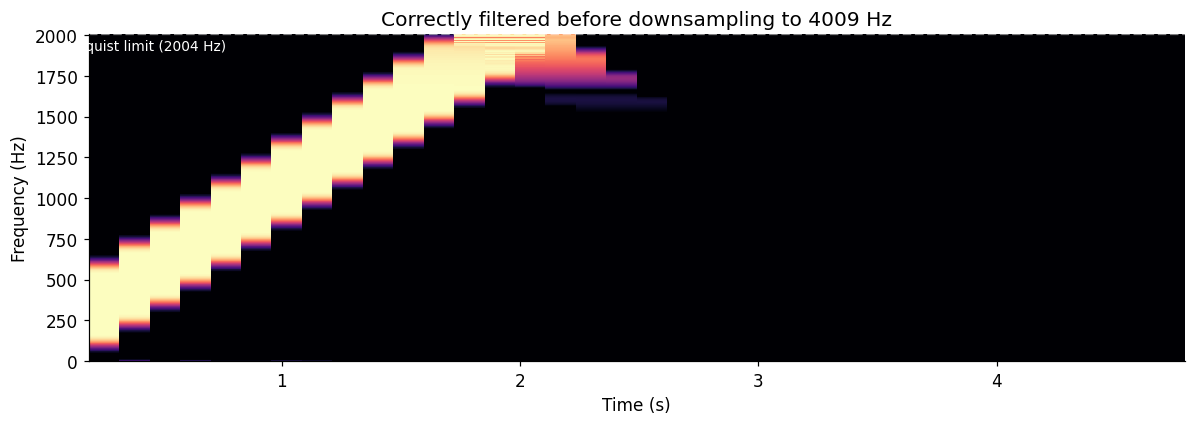

In [19]:
fig, ax = plt.subplots(figsize=(11, 4))
plot_spectrogram(ax, chirp_correct, fs_low,
                 f"Correctly filtered before downsampling to {fs_low} Hz",
                 fmax=fs_low / 2)
ax.axhline(fs_low / 2, color="white", linestyle="--", alpha=0.5)
ax.text(0.1, fs_low / 2 - 100, f"Nyquist limit ({fs_low/2:.0f} Hz)",
        color="white", fontsize=9)
plt.tight_layout()
plt.show()

### Side-by-side: the three spectrograms

Here are all three signals on the same figure. The story reads top to
bottom:

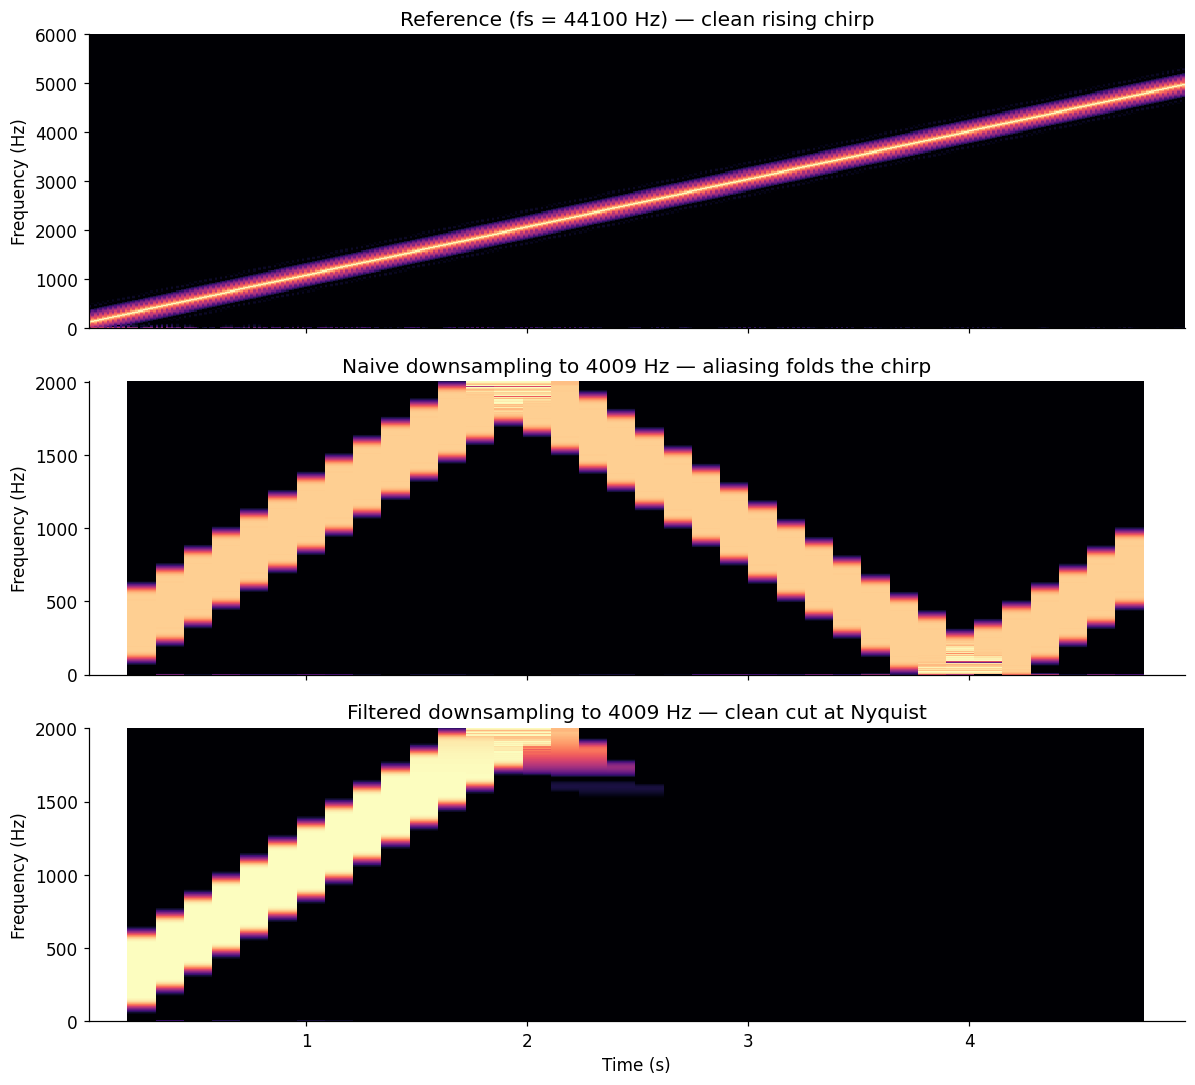

In [20]:
fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)

plot_spectrogram(axes[0], chirp_ref, fs_ref,
                 "Reference (fs = 44100 Hz) — clean rising chirp",
                 fmax=6000)
plot_spectrogram(axes[1], chirp_naive, fs_low,
                 f"Naive downsampling to {fs_low} Hz — aliasing folds the chirp",
                 fmax=fs_low / 2)
plot_spectrogram(axes[2], chirp_correct, fs_low,
                 f"Filtered downsampling to {fs_low} Hz — clean cut at Nyquist",
                 fmax=fs_low / 2)

for ax in axes:
    ax.set_xlabel("")
axes[-1].set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

The three signals were all derived from the same source. The only
difference between them is *how* — or *whether* — they were filtered
before being sampled at a lower rate.

The takeaway, in one sentence: **aliasing is not about sampling at the
wrong rate; it's about sampling without first removing what cannot be
represented at that rate.**

This is why every real-world digitizer — every microphone preamp, every
camera sensor, every analog-to-digital converter — has an anti-alias
filter built in. The signal processing chain begins with throwing away
what cannot be kept, so that what remains is honest.

The next act asks the reverse question: given a correctly sampled signal,
how do we *reconstruct* the continuous version?

## Act 4 — Putting it back together

Acts 1–3 were about what *goes wrong* when we sample. This act is about
what's possible when we sample correctly.

The sampling theorem makes a strong claim: a bandlimited signal sampled
above the Nyquist rate can be **exactly** reconstructed from its samples.
Not approximately, not "with small error" — *exactly*. The continuous
signal is fully determined by the discrete samples.

We will test this claim by reconstructing a known signal three ways:

1. **Zero-order hold** — what hardware does by default.
2. **Linear interpolation** — what your eye does when connecting dots.
3. **Sinc interpolation** — what the theorem actually requires.

Then we'll measure how close each one comes to the original.

### A test signal we know exactly

We use a sum of two sinusoids:

$$
x(t) = \sin(2\pi \cdot 50 \cdot t) + 0.6 \sin(2\pi \cdot 120 \cdot t)
$$

It is bandlimited with $f_\text{max} = 120$ Hz, so the Nyquist rate is
240 Hz. We sample at $f_s = 600$ Hz — comfortably above Nyquist — over
1 second. This gives us 600 samples to work with.

Because we know the closed-form expression, we can evaluate the *true*
continuous signal at any time and use it as ground truth. The plots
below zoom into the first 30 ms so the differences between methods are
visible at the scale of individual samples.

In [21]:
def true_signal(t):
    """The closed-form continuous signal we'll try to reconstruct."""
    return np.sin(2 * np.pi * 50 * t) + 0.6 * np.sin(2 * np.pi * 120 * t)

# Sampling
fs_test = 600                              # Hz
duration_test = 1.0                        # s
t_samples = np.arange(0, duration_test, 1 / fs_test)
x_samples = true_signal(t_samples)

# A dense grid representing "continuous time" for plotting & error eval
fs_eval = 50_000
t_eval = np.arange(0, duration_test, 1 / fs_eval)
x_true = true_signal(t_eval)

print(f"Sample rate: {fs_test} Hz (Nyquist rate: 240 Hz)")
print(f"Number of samples: {len(t_samples)}")
print(f"Number of evaluation points: {len(t_eval)}")

Sample rate: 600 Hz (Nyquist rate: 240 Hz)
Number of samples: 600
Number of evaluation points: 50000


### Method 1: Zero-order hold

Between consecutive samples, hold the value of the most recent sample
constant. The reconstructed signal is a staircase.

In [22]:
def reconstruct_zoh(t_samples, x_samples, t_eval):
    """For each t in t_eval, return x_samples[n] where n is the most recent
    sample index with t_samples[n] <= t."""
    # np.searchsorted finds insertion indices; subtract 1 for "most recent"
    indices = np.searchsorted(t_samples, t_eval, side="right") - 1
    indices = np.clip(indices, 0, len(x_samples) - 1)
    return x_samples[indices]

x_zoh = reconstruct_zoh(t_samples, x_samples, t_eval)
print(f"ZOH reconstruction computed: {len(x_zoh)} points")

ZOH reconstruction computed: 50000 points


### Method 2: Linear interpolation

Connect consecutive samples with straight line segments. NumPy provides
this directly via `np.interp`.

In [23]:
def reconstruct_linear(t_samples, x_samples, t_eval):
    """Linear interpolation between consecutive samples."""
    return np.interp(t_eval, t_samples, x_samples)

x_linear = reconstruct_linear(t_samples, x_samples, t_eval)
print(f"Linear reconstruction computed: {len(x_linear)} points")

Linear reconstruction computed: 50000 points


### Method 3: Sinc interpolation (Whittaker–Shannon)

Each sample contributes a sinc-shaped wave centered at its sample time,
scaled by the sample's value. The reconstruction is the sum of all these
sinc waves:

$$
x_\text{sinc}(t) = \sum_n x[n] \cdot \text{sinc}\left(\frac{t - t_n}{T_s}\right)
$$

where $T_s = 1/f_s$ is the sample interval and $\text{sinc}(x) = \sin(\pi x)/(\pi x)$.

**A note on implementation.** SciPy provides `scipy.signal.resample`,
which performs sinc-like reconstruction efficiently using the FFT. We
deliberately do not use it here. Building the reconstruction from its
mathematical definition — summing one sinc per sample — keeps the
connection between the formula and the code transparent, and it is the
implementation that most directly tests the theorem on its own terms.
This choice has consequences for numerical accuracy, which we examine in
the subsection following the error table.

For each evaluation point, we sum the contributions from every sample.

In [24]:
def reconstruct_sinc(t_samples, x_samples, t_eval, fs):
    """
    Whittaker-Shannon reconstruction.

    For each t in t_eval, compute the sum over all samples n of
    x[n] * sinc((t - t_n) * fs).

    np.sinc(x) computes sin(pi*x)/(pi*x), which is the normalized sinc.
    """
    # Build a 2D matrix of shape (len(t_eval), len(t_samples))
    # where entry [i, n] is sinc((t_eval[i] - t_samples[n]) * fs)
    T_s = 1 / fs
    # Broadcasting: t_eval[:, None] has shape (M, 1), t_samples has shape (N,)
    # The result has shape (M, N)
    sinc_matrix = np.sinc((t_eval[:, None] - t_samples[None, :]) / T_s)
    # Multiply each column by the corresponding sample value, then sum across n
    return sinc_matrix @ x_samples

x_sinc = reconstruct_sinc(t_samples, x_samples, t_eval, fs_test)
print(f"Sinc reconstruction computed: {len(x_sinc)} points")

Sinc reconstruction computed: 50000 points


### Visual comparison

We zoom into the first 30 ms of the signal so the differences between
methods are visible. The original signal is the gray curve; the colored
curves are the three reconstructions; the dots are the samples we used.

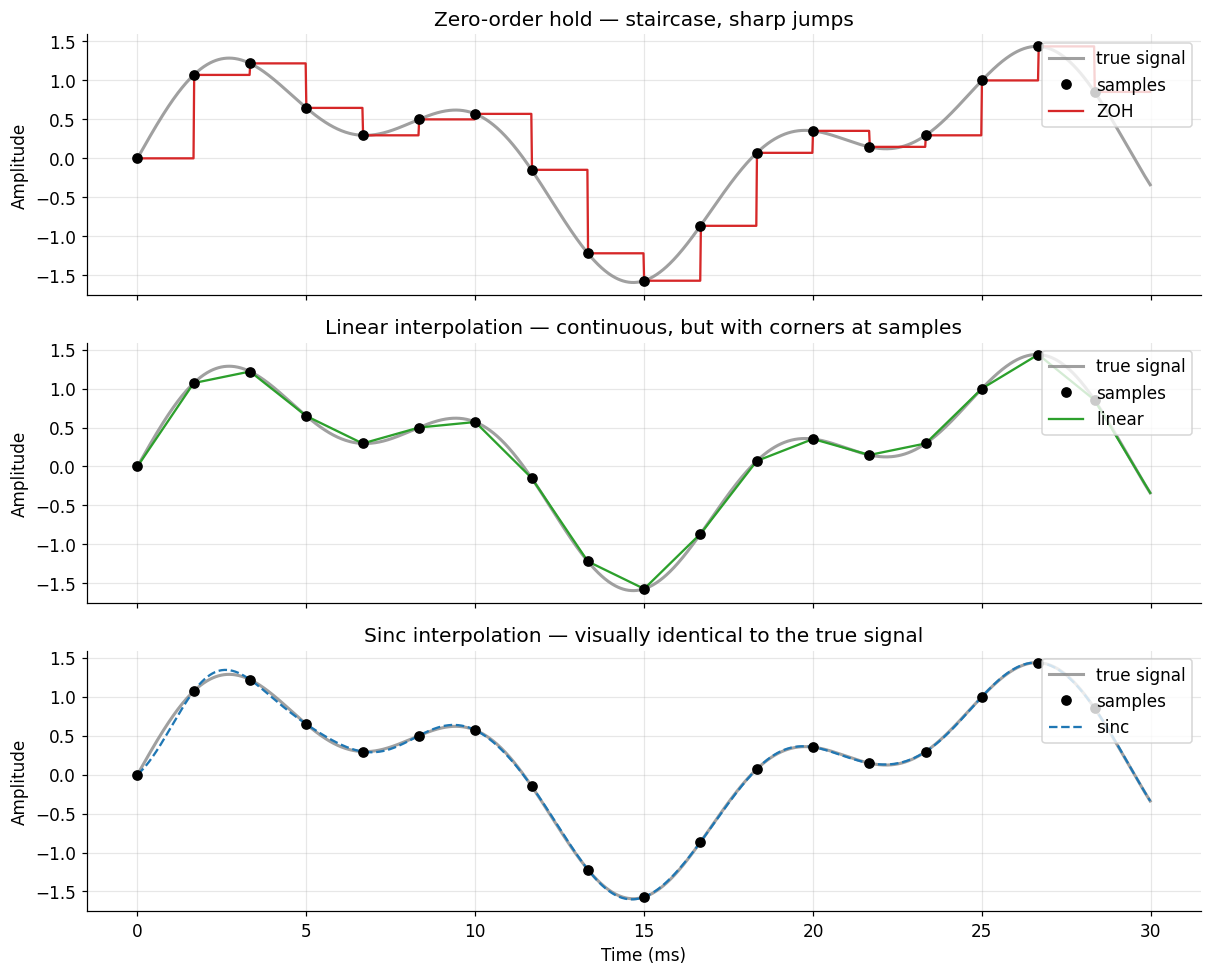

In [25]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, sharey=True)

zoom_end = 0.03  # show first 30 ms
mask = t_eval <= zoom_end
mask_samples = t_samples <= zoom_end

# Common elements for each subplot
def add_truth_and_samples(ax):
    ax.plot(t_eval[mask] * 1000, x_true[mask], color="#888",
            linewidth=2, label="true signal", alpha=0.8)
    ax.plot(t_samples[mask_samples] * 1000, x_samples[mask_samples],
            "o", color="black", markersize=6, label="samples", zorder=5)
    ax.set_ylabel("Amplitude")
    ax.grid(True, alpha=0.3)

# Panel 1: Zero-order hold
add_truth_and_samples(axes[0])
axes[0].plot(t_eval[mask] * 1000, x_zoh[mask],
             color="#d62728", linewidth=1.5, label="ZOH")
axes[0].set_title("Zero-order hold — staircase, sharp jumps")
axes[0].legend(loc="upper right")

# Panel 2: Linear
add_truth_and_samples(axes[1])
axes[1].plot(t_eval[mask] * 1000, x_linear[mask],
             color="#2ca02c", linewidth=1.5, label="linear")
axes[1].set_title("Linear interpolation — continuous, but with corners at samples")
axes[1].legend(loc="upper right")

# Panel 3: Sinc
add_truth_and_samples(axes[2])
axes[2].plot(t_eval[mask] * 1000, x_sinc[mask],
             color="#1f77b4", linewidth=1.5, label="sinc", linestyle="--")
axes[2].set_title("Sinc interpolation — visually identical to the true signal")
axes[2].set_xlabel("Time (ms)")
axes[2].legend(loc="upper right")

plt.tight_layout()
plt.show()

The eye already tells most of the story:

- **ZOH** clearly fails. The staircase deviates from the smooth curve
  visibly, especially where the signal is changing fastest.
- **Linear** does much better but still has visible corners at sample
  points. Between samples it tends to "cut the curve short" wherever
  the underlying signal is curved.
- **Sinc** is indistinguishable from the true signal. The dashed blue
  line lies directly on the gray curve.

But "indistinguishable" is a claim we should verify quantitatively.

### Quantitative comparison

We compute two error metrics for each method:

- **Maximum absolute error** — the worst-case deviation across the
  whole signal. Catches local catastrophes.
- **Root-mean-square (RMS) error** — average squared deviation.
  Catches overall accuracy.

We exclude the outer 40% of the time window when evaluating sinc — that
is, we measure error only in the central interval $[0.4, 0.6]$ s. At
the boundaries, the "missing" samples that would extend before $t = 0$
or after $t = 1$ s cannot contribute to the sinc reconstruction, which
slightly degrades accuracy near the edges. The trimmed central window
isolates the method's behaviour from this finite-window artifact, which
we examine in the next subsection.

In [26]:
def error_metrics(x_true_arr, x_recon_arr, mask=None):
    """Return (max_abs_error, rms_error) over the masked region."""
    if mask is None:
        mask = np.ones_like(x_true_arr, dtype=bool)
    diff = x_recon_arr[mask] - x_true_arr[mask]
    return np.max(np.abs(diff)), np.sqrt(np.mean(diff ** 2))

# Evaluate errors only in the central 60% of the time window,
# avoiding edge effects for the sinc method.
margin = 0.4 * duration_test
center_mask = (t_eval >= margin) & (t_eval <= duration_test - margin)

max_zoh,   rms_zoh    = error_metrics(x_true, x_zoh,    center_mask)
max_lin,   rms_lin    = error_metrics(x_true, x_linear, center_mask)
max_sinc,  rms_sinc   = error_metrics(x_true, x_sinc,   center_mask)

print(f"{'Method':<12} {'Max abs error':>18} {'RMS error':>18}")
print("-" * 50)
print(f"{'ZOH':<12} {max_zoh:>18.6e} {rms_zoh:>18.6e}")
print(f"{'Linear':<12} {max_lin:>18.6e} {rms_lin:>18.6e}")
print(f"{'Sinc':<12} {max_sinc:>18.6e} {rms_sinc:>18.6e}")

Method            Max abs error          RMS error
--------------------------------------------------
ZOH                1.201083e+00       3.631091e-01
Linear             1.419923e-01       6.164408e-02
Sinc               7.773420e-04       5.353418e-04


### A finite-window subtlety

The sinc reconstruction is not exact, even though the theorem promises
exactness. The reason is in the small print: the theorem assumes
**infinitely many samples extending forward and backward in time**.
Our signal is finite — we only have samples in $[0, T]$ — so each sinc
function in the reconstruction is missing the contributions of the
infinitely many samples that *would* have existed outside this window.

Sinc tails decay slowly (as $1/n$), so this truncation effect leaks
inward from the boundaries and contaminates even the central region of
the reconstruction.

We can verify this scaling experimentally. If we keep everything else
fixed and increase the window length $T$, the truncation error should
decrease as $1/T$ (because the boundary samples we're missing are
proportionally further away).

T =  0.05 s,  N =    30 samples,  sinc RMS error = 6.621e-03
T =  0.10 s,  N =    60 samples,  sinc RMS error = 5.348e-03
T =  0.20 s,  N =   120 samples,  sinc RMS error = 2.675e-03
T =  0.50 s,  N =   300 samples,  sinc RMS error = 1.070e-03
T =  1.00 s,  N =   600 samples,  sinc RMS error = 5.352e-04
T =  2.00 s,  N =  1200 samples,  sinc RMS error = 2.676e-04
T =  5.00 s,  N =  3000 samples,  sinc RMS error = 1.070e-04


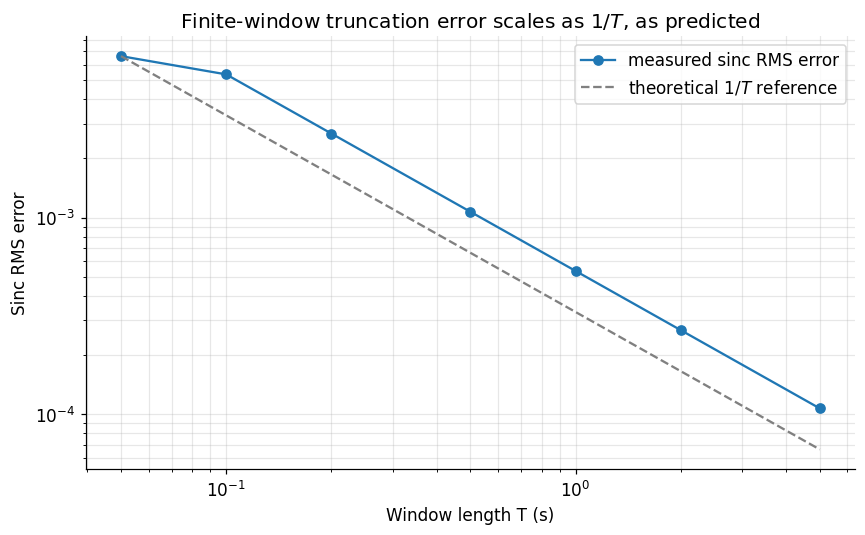

In [27]:
# Test sinc reconstruction error at a range of window lengths.
# We evaluate the reconstruction only in the central 20% of each window
# (where the error is measured), with a moderate density that's plenty
# for an RMS estimate but small enough to keep memory in check.
window_lengths = [0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0]
sinc_errors = []
n_eval_in_center = 2000   # evaluation points inside the central region

for T_test in window_lengths:
    # Sample the signal at fs_test over [0, T_test]
    t_s = np.arange(0, T_test, 1 / fs_test)
    x_s = true_signal(t_s)

    # Evaluate only inside the central 20% of the window
    center_start = 0.4 * T_test
    center_end   = 0.6 * T_test
    t_e = np.linspace(center_start, center_end, n_eval_in_center)
    x_t = true_signal(t_e)
    x_r = reconstruct_sinc(t_s, x_s, t_e, fs_test)

    rms = np.sqrt(np.mean((x_r - x_t) ** 2))
    sinc_errors.append(rms)
    print(f"T = {T_test:>5.2f} s,  N = {len(t_s):>5} samples,  sinc RMS error = {rms:.3e}")

# Log-log plot — slope of -1 indicates 1/T scaling
fig, ax = plt.subplots(figsize=(8, 5))
ax.loglog(window_lengths, sinc_errors, "o-", color="#1f77b4",
          label="measured sinc RMS error")

T_arr = np.array(window_lengths)
ref = sinc_errors[0] * (window_lengths[0] / T_arr)
ax.loglog(window_lengths, ref, "--", color="gray",
          label="theoretical $1/T$ reference")

ax.set_xlabel("Window length T (s)")
ax.set_ylabel("Sinc RMS error")
ax.set_title("Finite-window truncation error scales as $1/T$, as predicted")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

The plot confirms the prediction. For window lengths from about 0.2 s
upward, the measured error tracks the $1/T$ reference line closely —
both have slope $-1$ on log-log axes, so the error genuinely decays in
proportion to $1/T$. At the two shortest windows, the measured error
sits slightly above the reference, which is also expected: with only a
few dozen samples, additional finite-sample effects dominate, and the
clean $1/T$ asymptotic only takes over once $N$ is reasonably large.

The conclusion: sinc reconstruction is exact in the limit of an
infinite signal, and the error we see in any finite computation is
the **measurable cost of having a finite signal**. It is not a flaw in
the method; it is a faithful reflection of the theorem's underlying
assumption.

The numbers tell the same story the eye did, but precisely:

- **ZOH** has errors of order $10^{-1}$ — about 10% of the signal's amplitude.
- **Linear** is roughly an order of magnitude better, but still has clearly
  measurable error.
- **Sinc** is two more orders of magnitude better than linear — but, notably,
  *not* zero. The next subsection examines why.

### Why these results, in one sentence each

- **ZOH adds spurious high-frequency content** because staircases have
  sharp jumps, and sharp jumps in time mean broadband noise in frequency.
  The reconstructed signal contains energy at frequencies the original
  signal never had.

- **Linear interpolation also adds high-frequency content** — less than
  ZOH, because there are no jumps, but the corners at sample points
  still introduce energy above $f_s/2$.

- **Sinc interpolation adds nothing** because each sinc function is
  exactly bandlimited to $[-f_s/2, +f_s/2]$. A sum of bandlimited
  functions is bandlimited. So the reconstruction lives in the same
  frequency band as the original — and if the original was already
  fully captured by the samples (which it is, by Nyquist), there is
  nothing left to differ.

### What we've proven

Across four acts, we have walked the full sampling pipeline:

| Act | Question | Answer |
|---|---|---|
| 1 | What does aliasing look like? | A signal lying about its frequency. |
| 2 | Why does it happen? | Spectral copies fold into the visible band. |
| 3 | What does it sound like? | A chirp that reverses direction. |
| 4 | Can we undo sampling? | Yes — exactly — if we sampled correctly. |

The Nyquist–Shannon sampling theorem is not an approximation. It is a
statement about an exact equivalence between continuous signals and their
samples, *provided* the bandlimit and sampling-rate conditions are met.
When they are, sinc interpolation recovers the continuous signal exactly.
When they aren't, no reconstruction method can recover it — the
information was destroyed at the moment of sampling.

The final act is interactive: a widget for exploring this entire
parameter space yourself.

## Act 5 — Play with it

The four previous acts each looked at sampling from one fixed angle —
time, frequency, audio, reconstruction. The interactive widget at
[`widget/interactive.html`](widget/interactive.html) lets you see the
parameter space, with all three of our
analytical perspectives (time domain, spectrum, spectral folding)
updating together as the parameters change.

A slider steps through 12 scenarios, ordered to tell a deliberate story:
the first three illustrate comfortable, well-sampled cases; scenario 4 is
the first failure where Nyquist is broken; scenarios 5–7 explore
ordinary aliasing of increasing severity; scenarios 8 and 9 reveal the
striking *DC trap* where any integer multiple of $f_s$ aliases all the
way down to 0 Hz; and scenarios 10–12 walk back to safe territory,
closing the arc. Scenario 6 deliberately reproduces the 440 Hz / 600 Hz
example that opened Act 1.

To open the widget, double-click `widget/interactive.html` in any file
browser. **No installation is required** — it runs entirely in the
browser, with no Python or server.

A reading suggestion: walk through the scenarios in order on first
viewing. Each one is a single step in an argument; reading them out of
sequence loses the narrative. 

---

*This concludes the project. The widget, the audio files, the figures, and
this notebook together form a complete, hands-on tour of the
Nyquist–Shannon sampling theorem and its consequences.*